In [1]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
# using Revise
import Deborah.Rebekah; flush(stdout); flush(stderr)
import Deborah.RebekahMiriam;  flush(stdout); flush(stderr)

┌ Info: lib_lightgbm found in system dirs!
└ @ LightGBM /home/benjamin/.julia/packages/LightGBM/qTqmS/src/LightGBM.jl:37


In [2]:
SAVE_DIR="sample"
ns="12"
nt="4"
beta="1.60"
# model="Plaq-Rect-Loop-TrM1_GBM_Plaq-Rect-Loop-TrM2_GBM_Plaq-Rect-Loop-TrM3_GBM_Plaq-Rect-Loop-TrM4_GBM"
model="Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"
# model="TrM1-TrM1_BAS_TrM1-TrM2_GBM_TrM1-TrM3_GBM_TrM1-TrM4_GBM"

"Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"

In [3]:
overall_name="L$(ns)T$(nt)b$(beta)_$(model)"

# --- Load result ---
result = Rebekah.JLD2Loader.load_jld2_Miriam(localpath("$(SAVE_DIR)/results_$(overall_name).jld2"))

rw_data = result.rw_data
new_dict = result.summary
new_dict_trace_meas = result.summary_trace_meas
new_dict_moment_meas = result.summary_moment_meas
new_dict_cumulant_meas = result.summary_cumulant_meas
kappa_list = result.kappa_list
labels = result.labels
trains = result.trains

labels_int = parse.(Int, labels)
trains_int = parse.(Int, trains)   

Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

save_flag=false

false

In [4]:
Q_tags = [:Q_BS, :Q_JK, :Q_P1, :Q_P2]
Q_keys = [:Q1,   :Q2,   :Q3,   :Q4  ]
moment_tex_doc = ["\$Q_1\$", "\$Q_2\$", "\$Q_3\$", "\$Q_4\$"]
pred_tags = [:Q_P1, :Q_P2]
orig_tag  = :Q_BS
display(kappa_list)

5-element Vector{String}:
 "13575"
 "13577"
 "13580"
 "13582"
 "13585"

In [5]:
chosen_key = :Q4
chosen_keyword = kappa_list[1]

"13575"

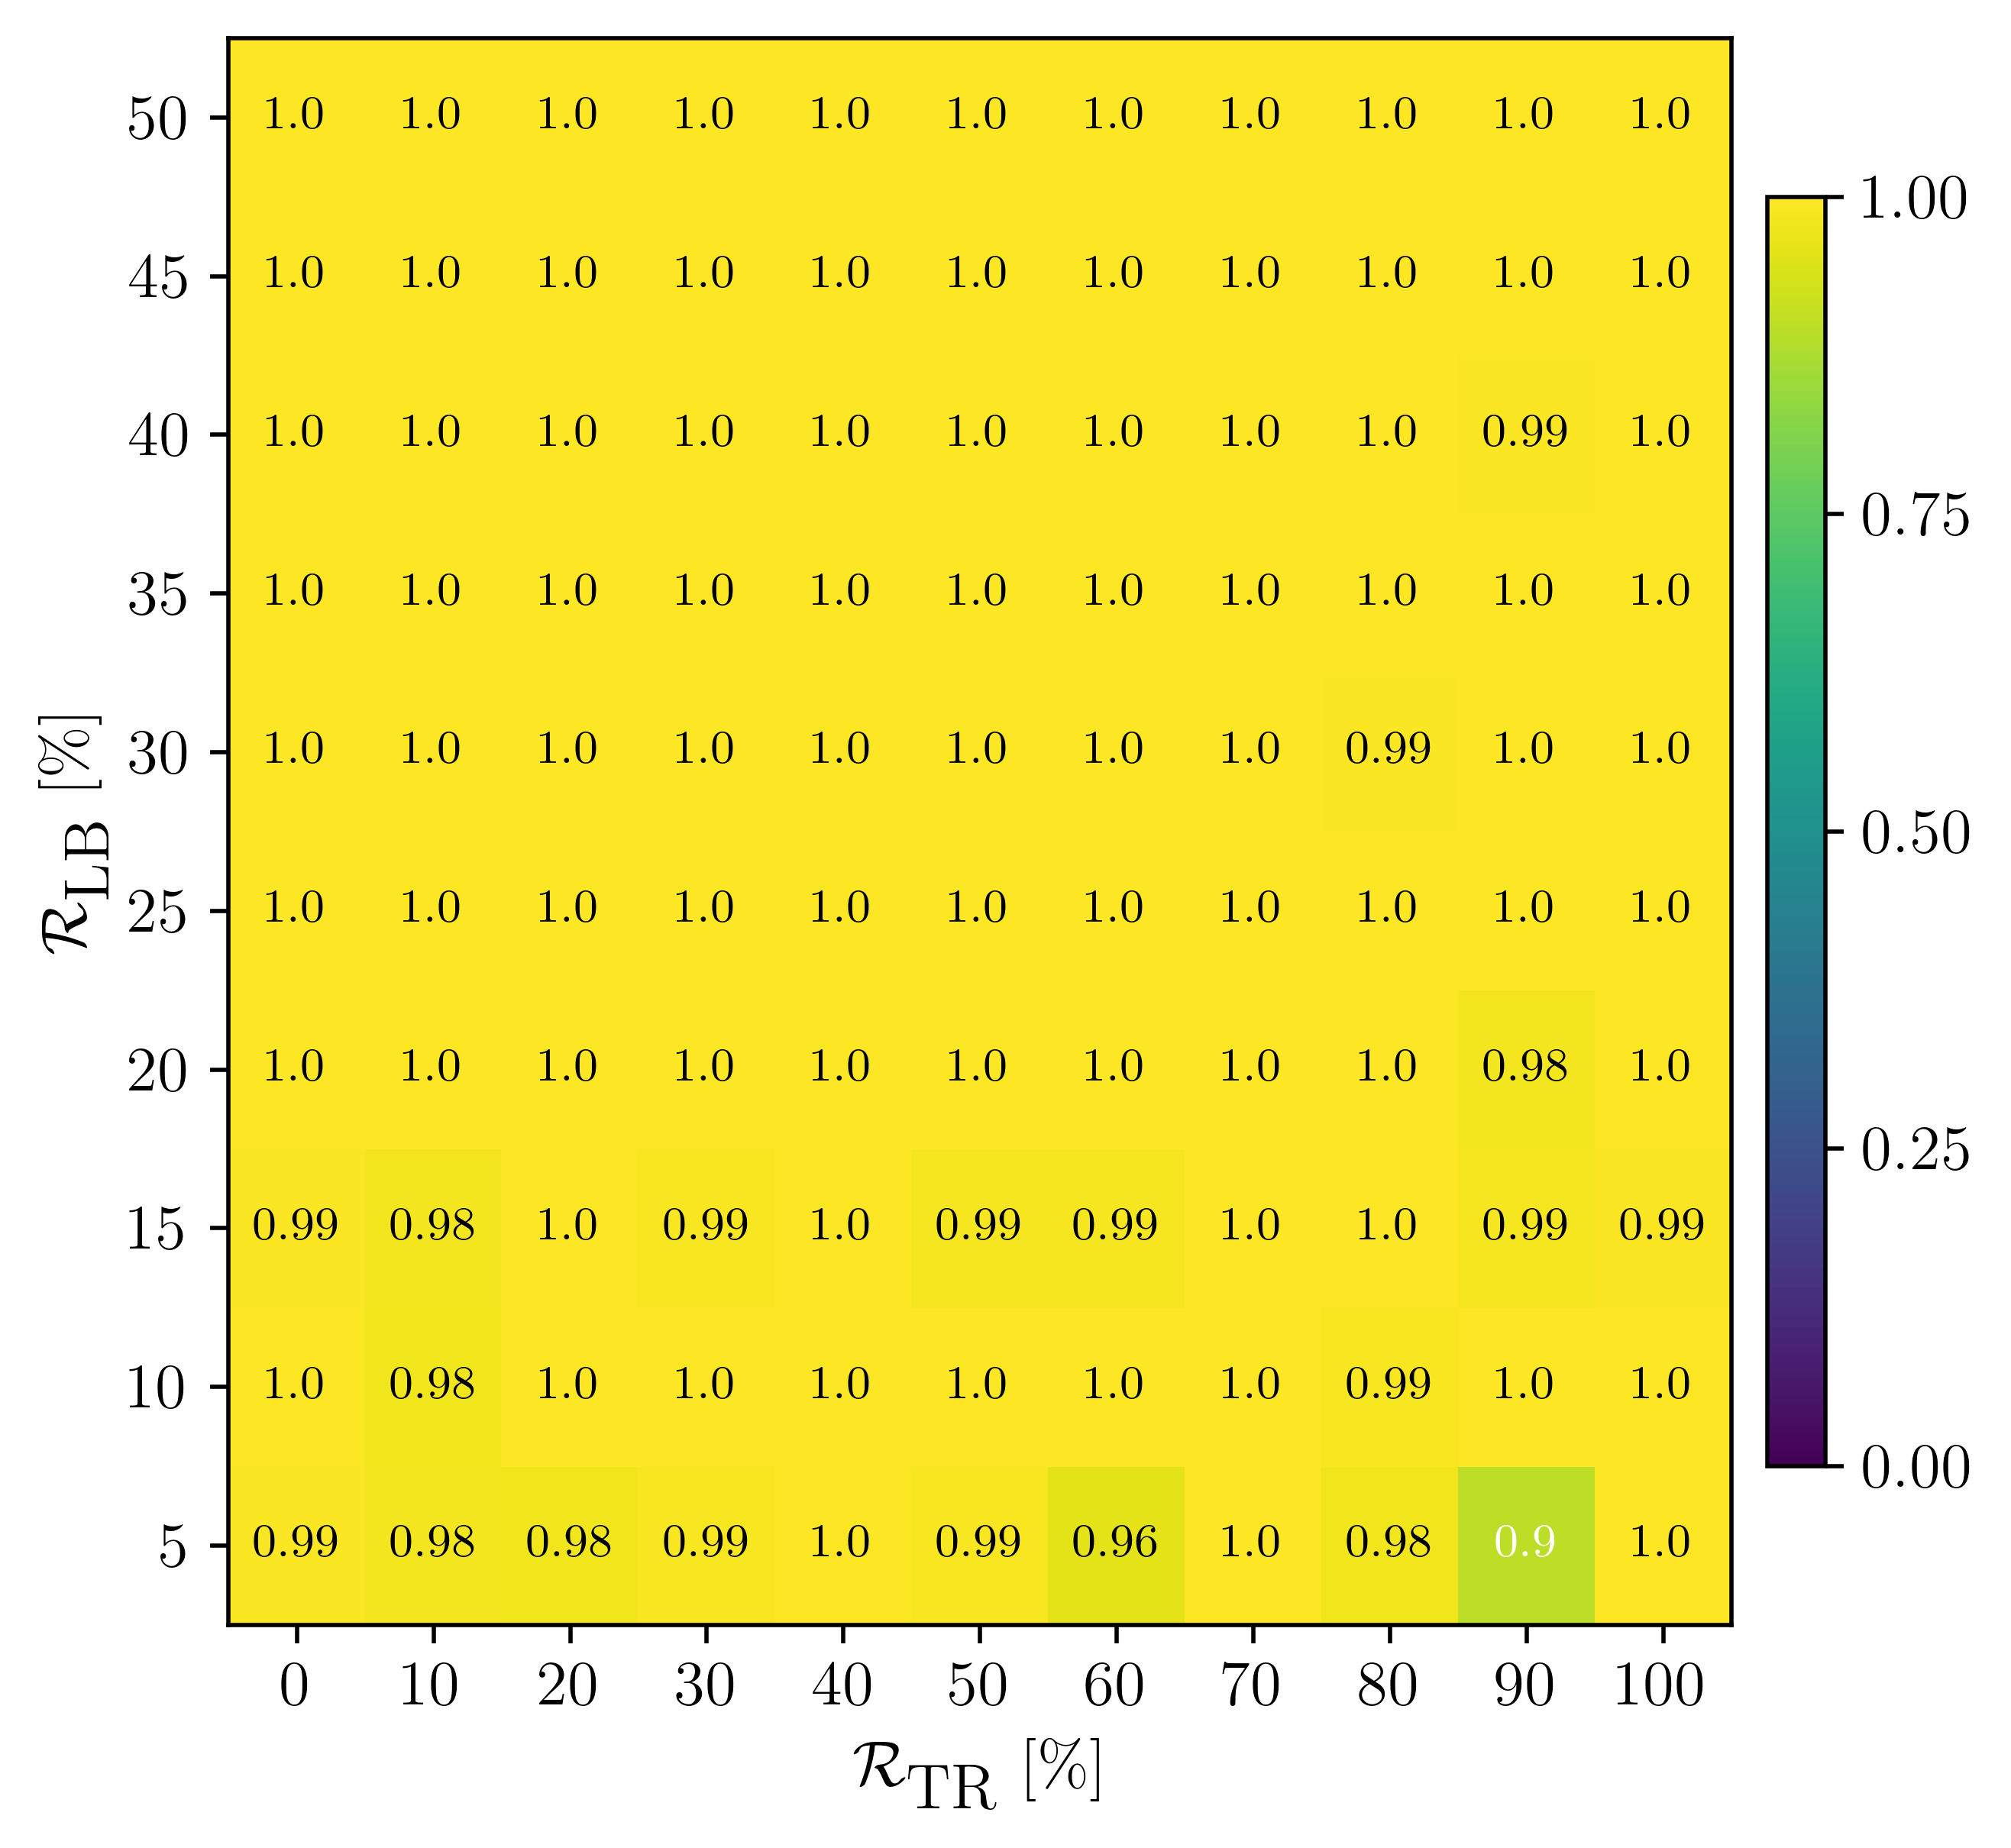

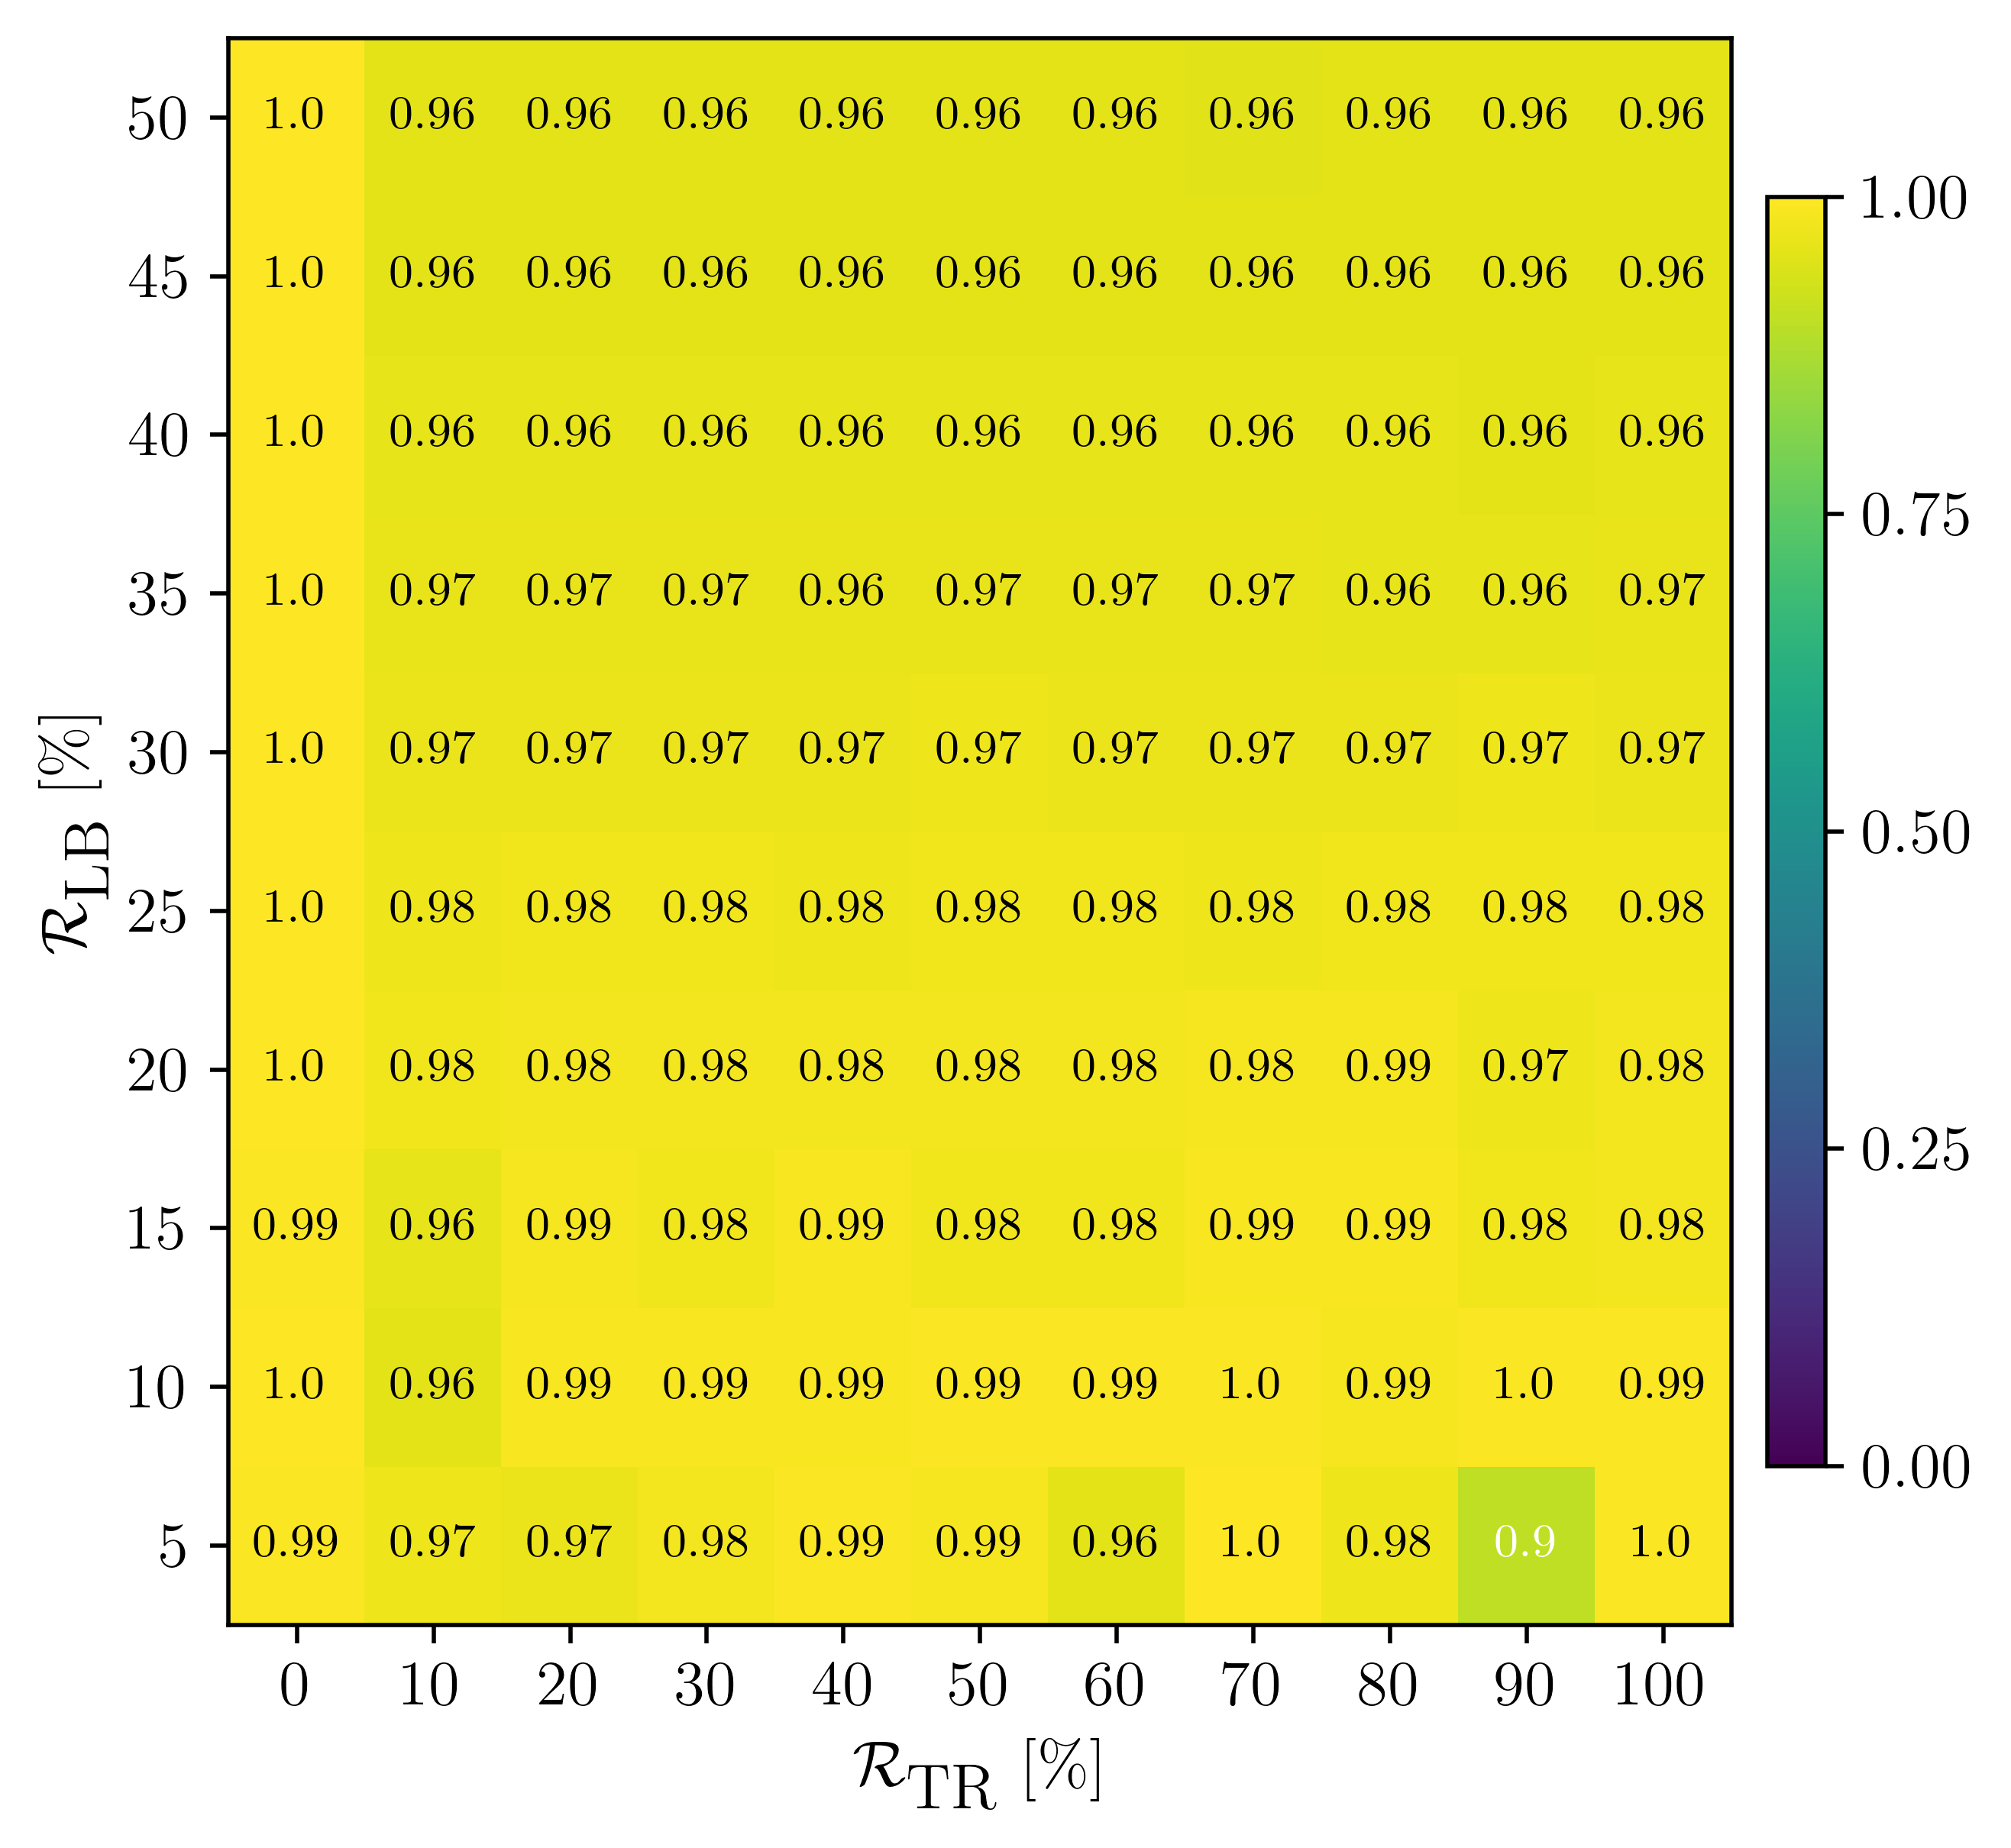

In [6]:
chosen_tag = :Q_P1

idx = findfirst(isequal(chosen_key), Q_keys)
chosen_key_tex = moment_tex_doc[idx]

bc_dict, _ = RebekahMiriam.ComparisonRebekahMiriam.build_bhattacharyya_dicts_for_measurements(
    new_dict_moment_meas,
    Q_keys,
    kappa_list,
    pred_tags,
    orig_tag,
    labels,
    trains
)

BCD = bc_dict[(chosen_key, chosen_tag, chosen_keyword)]

RebekahMiriam.HeatmapsRebekahMiriam.render_bhattacharyya_heatmap_for_measurements(
	BCD, 
	labels_int, 
	trains_int, 
	chosen_key, 
	chosen_tag, 
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)

chosen_tag = :Q_P2

idx = findfirst(isequal(chosen_key), Q_keys)
chosen_key_tex = moment_tex_doc[idx]

bc_dict, _ = RebekahMiriam.ComparisonRebekahMiriam.build_bhattacharyya_dicts_for_measurements(
    new_dict_moment_meas,
    Q_keys,
    kappa_list,
    pred_tags,
    orig_tag,
    labels,
    trains
)

BCD = bc_dict[(chosen_key, chosen_tag, chosen_keyword)]

RebekahMiriam.HeatmapsRebekahMiriam.render_bhattacharyya_heatmap_for_measurements(
	BCD, 
	labels_int, 
	trains_int, 
	chosen_key, 
	chosen_tag, 
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)

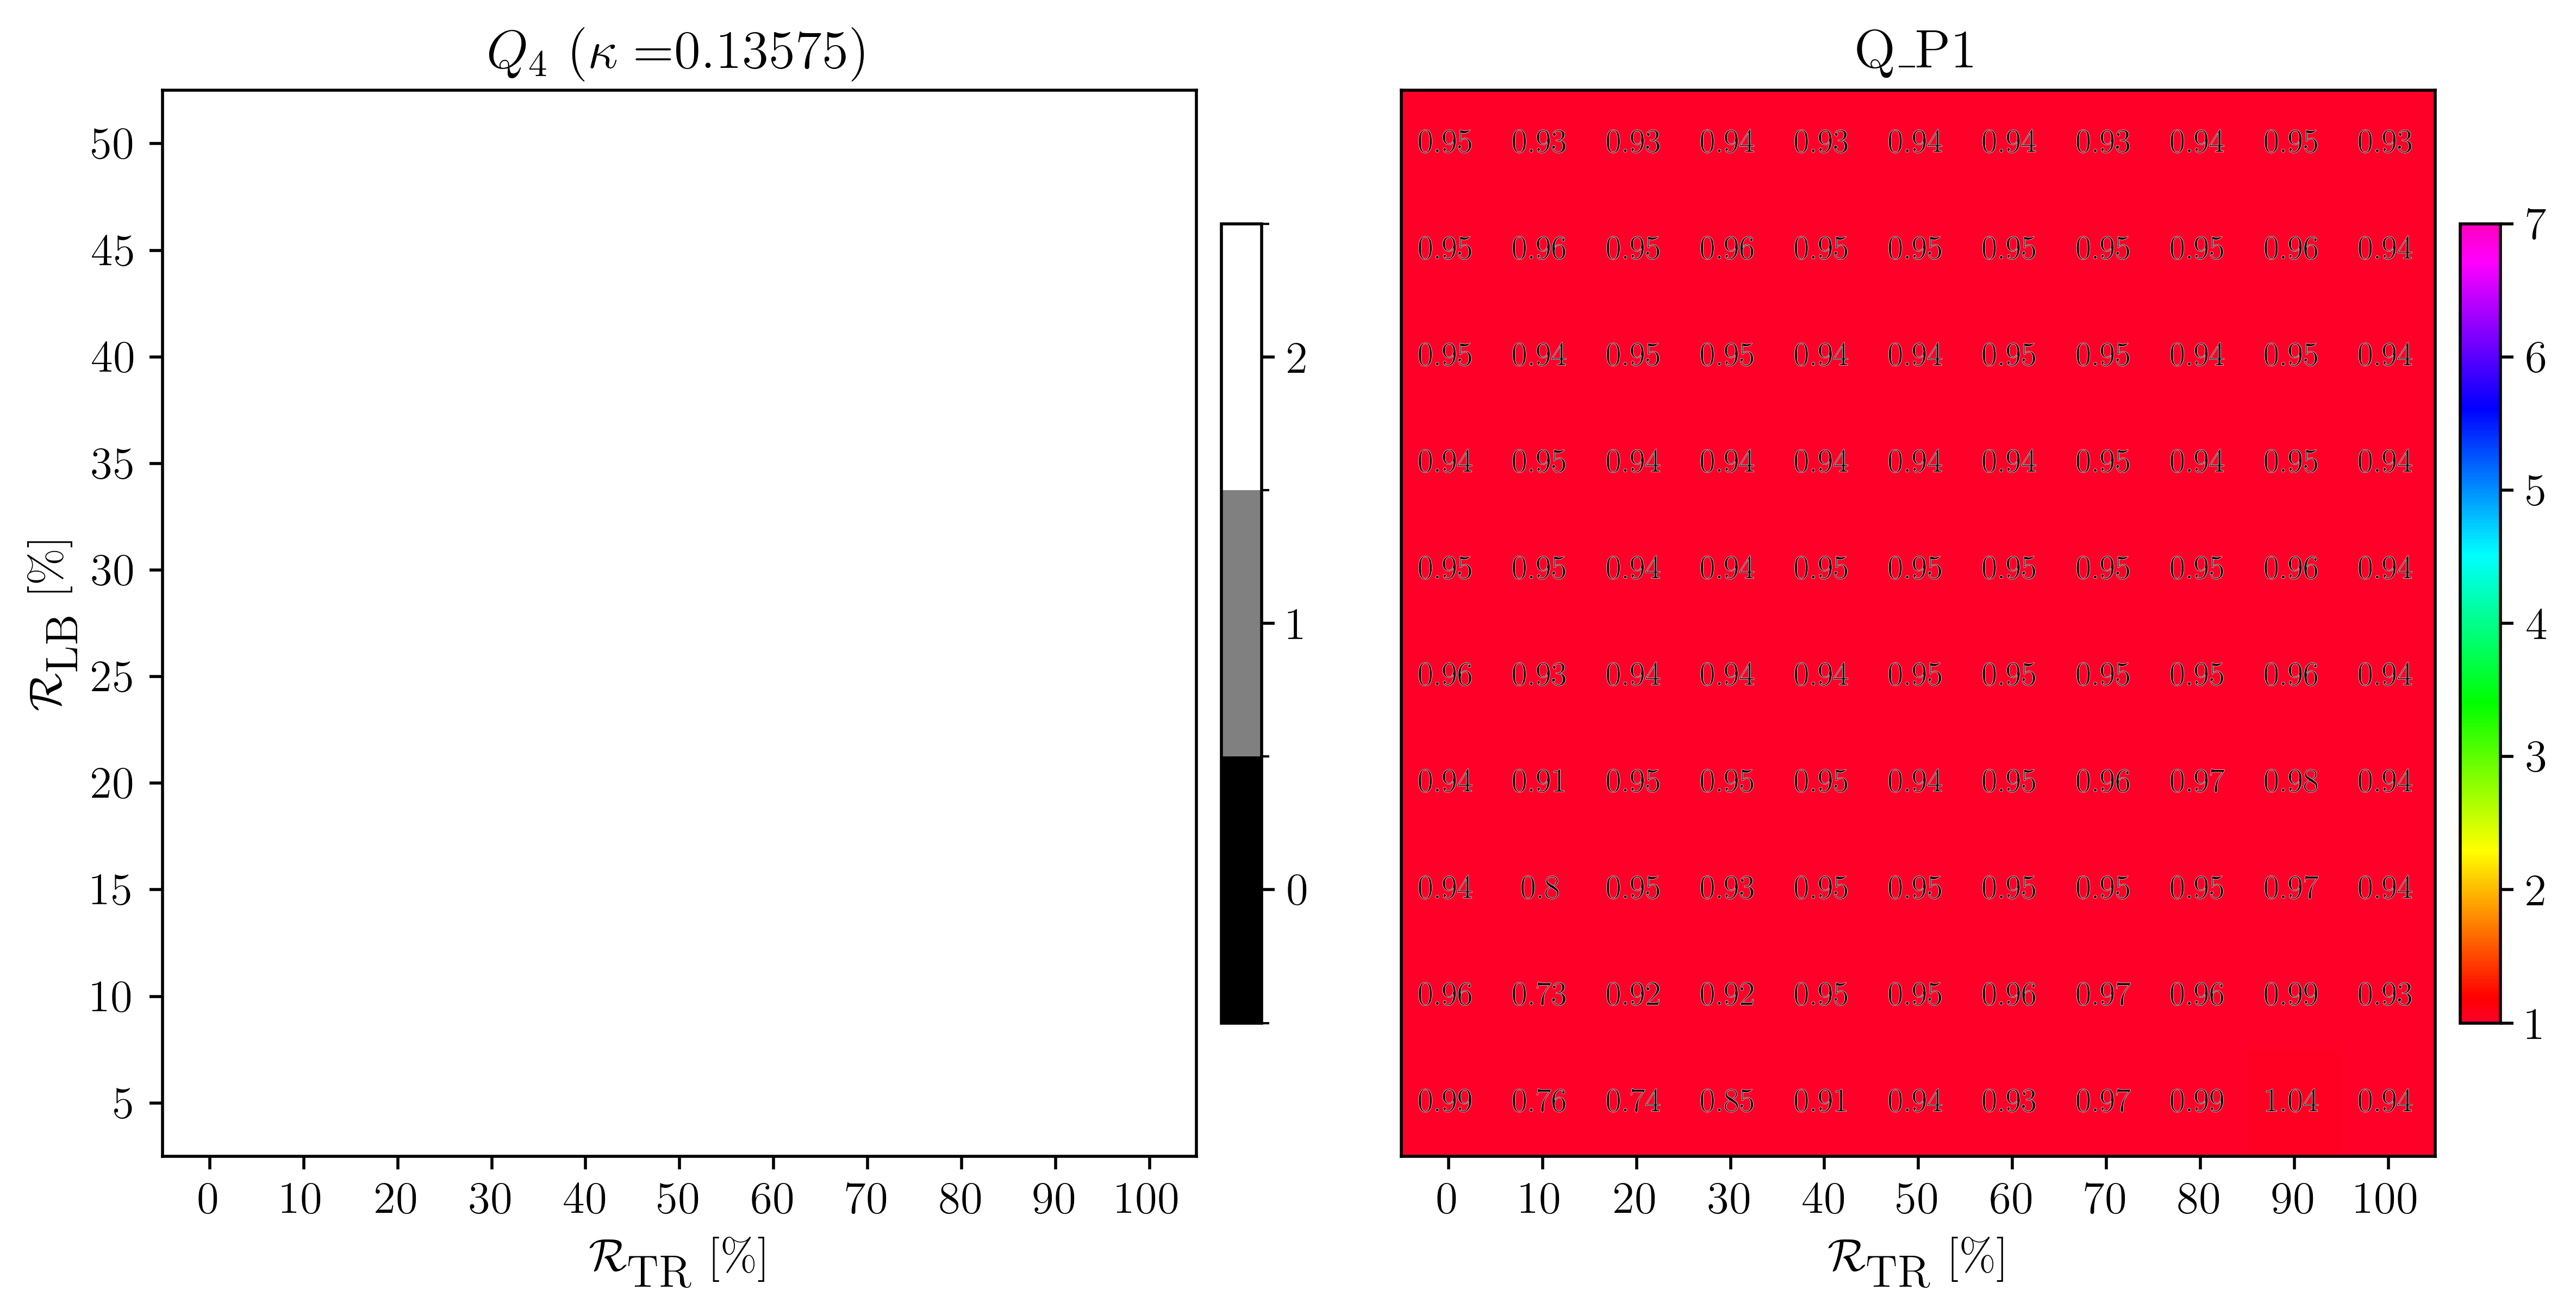

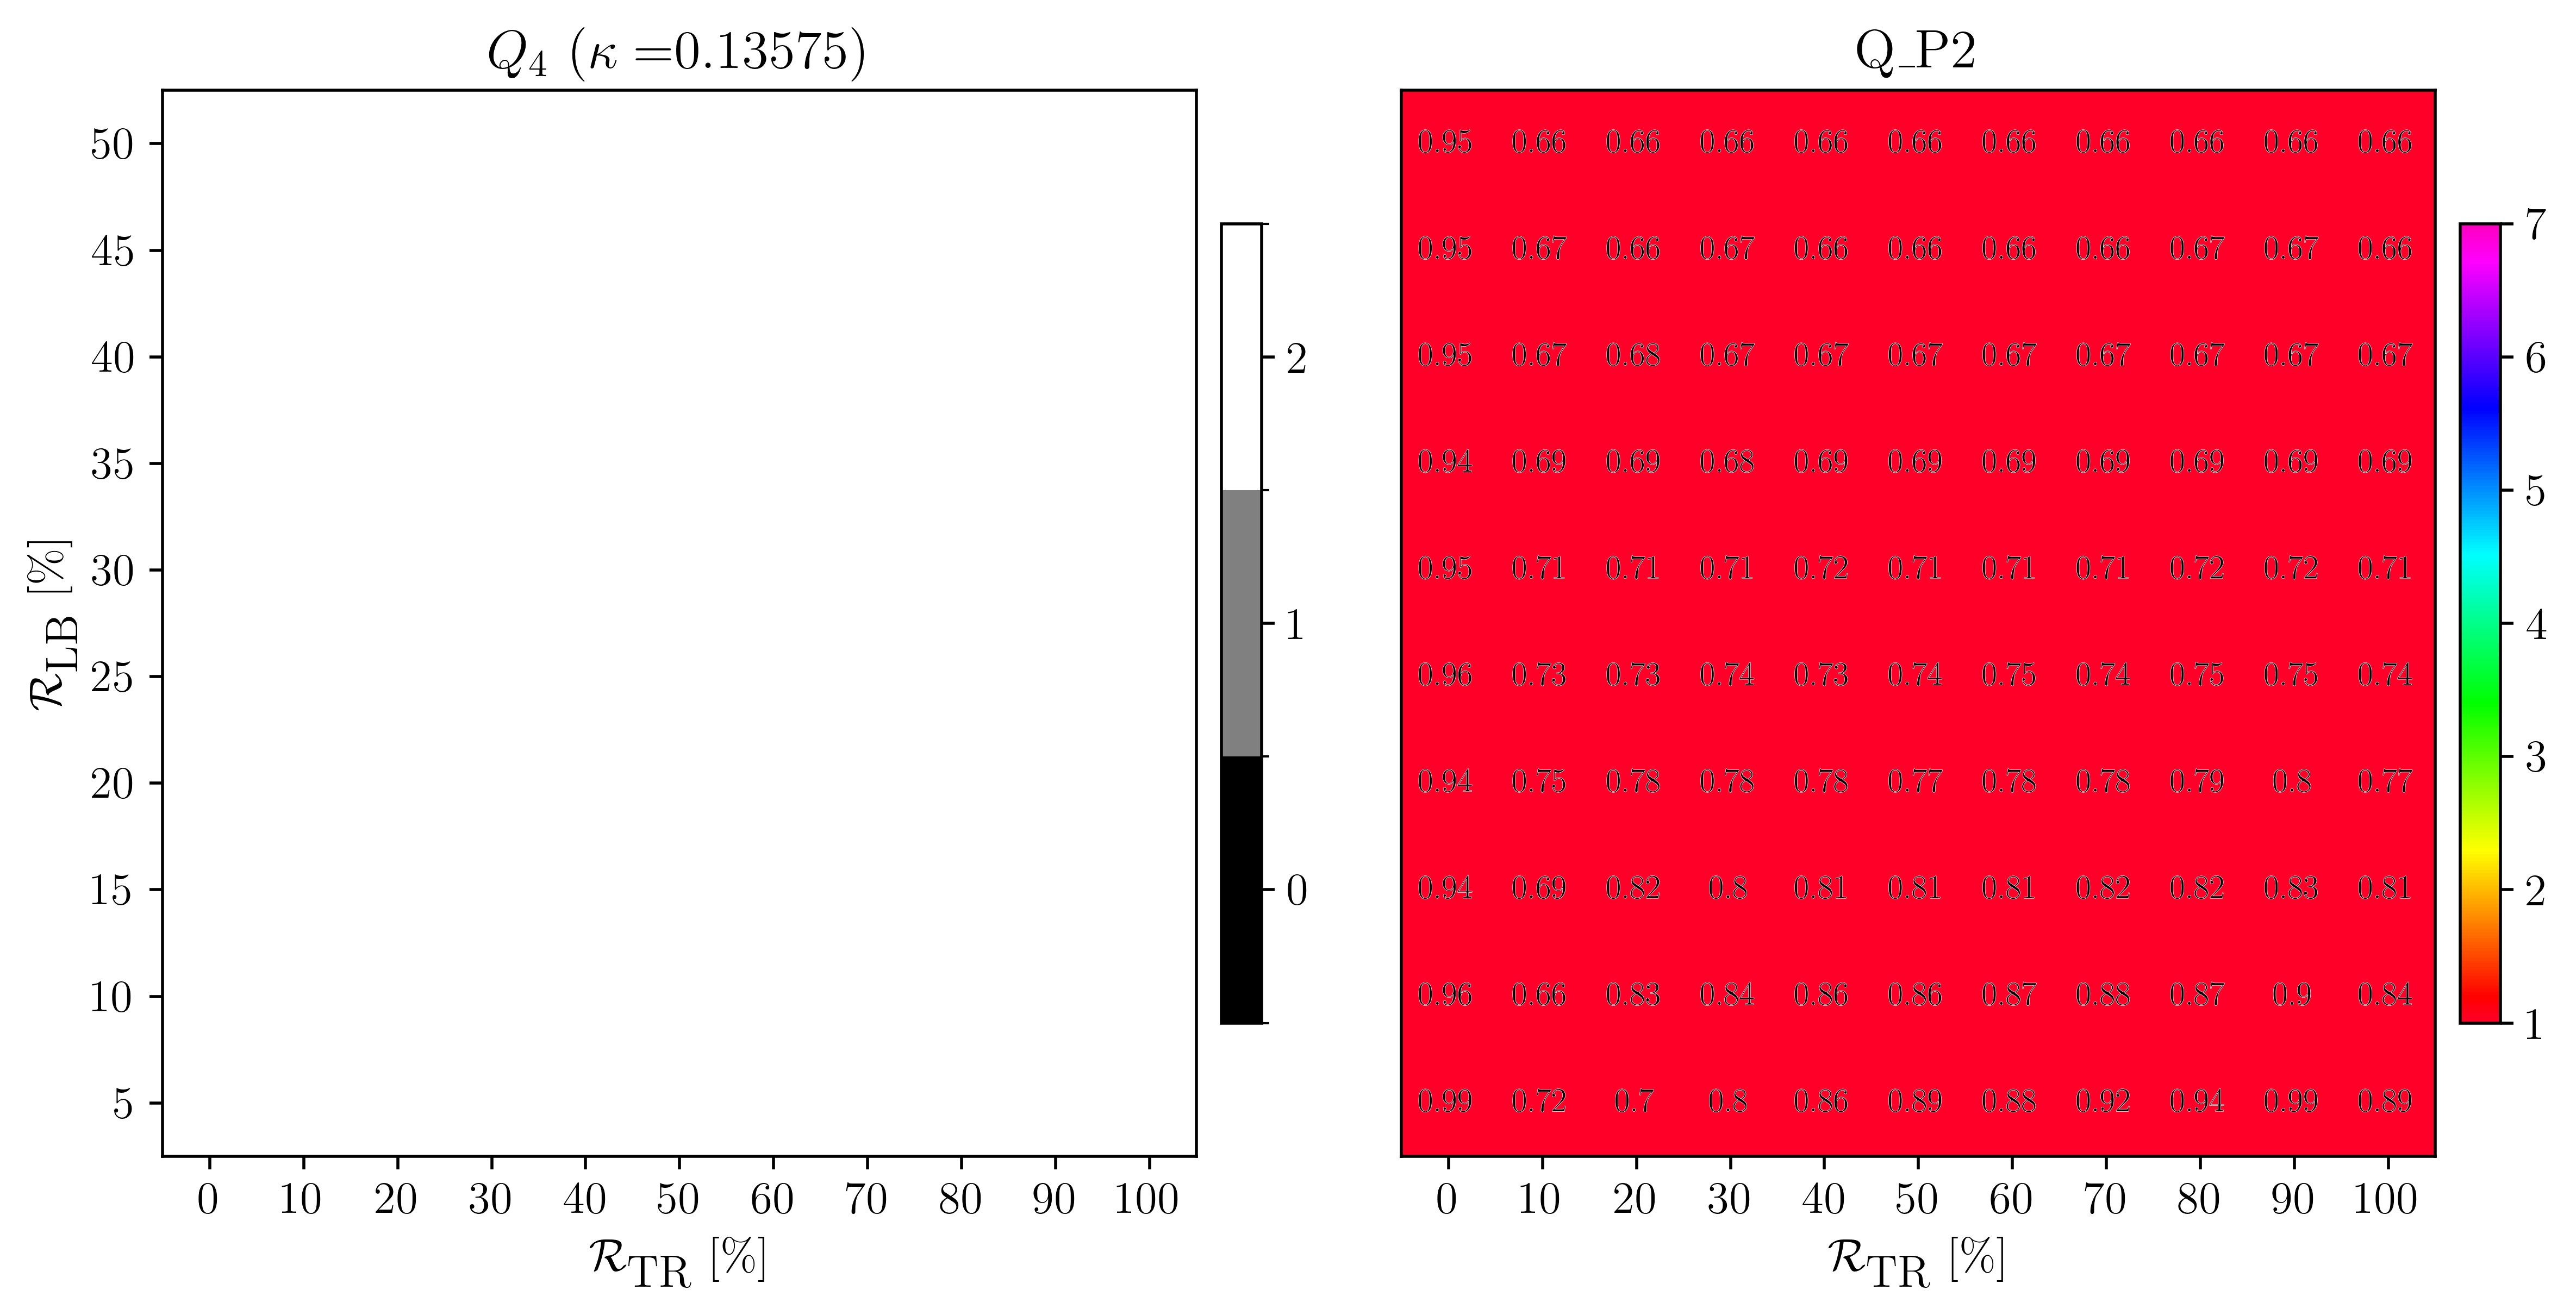

In [7]:
chosen_tag = :Q_P1

idx = findfirst(isequal(chosen_key), Q_keys)
chosen_key_tex = moment_tex_doc[idx]

chk_dict, err_dict = RebekahMiriam.ComparisonRebekahMiriam.build_overlap_and_error_dicts_for_measurements(
    new_dict_moment_meas,
    Q_keys,
    kappa_list,
    pred_tags,
    orig_tag,
    labels,
    trains
)

CHK = chk_dict[(chosen_key, chosen_tag, chosen_keyword)]
ERR = err_dict[(chosen_key, chosen_tag, chosen_keyword)]

RebekahMiriam.HeatmapsRebekahMiriam.render_overlap_and_error_heatmaps_for_measurements(
	CHK, 
	ERR, 
	labels_int, 
	trains_int, 
	chosen_key, 
	chosen_tag, 
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)

chosen_tag = :Q_P2

idx = findfirst(isequal(chosen_key), Q_keys)
chosen_key_tex = moment_tex_doc[idx]

chk_dict, err_dict = RebekahMiriam.ComparisonRebekahMiriam.build_overlap_and_error_dicts(
    new_dict_moment_meas,
    Q_keys,
    kappa_list,
    pred_tags,
    orig_tag,
    labels,
    trains
)

CHK = chk_dict[(chosen_key, chosen_tag, chosen_keyword)]
ERR = err_dict[(chosen_key, chosen_tag, chosen_keyword)]

RebekahMiriam.HeatmapsRebekahMiriam.render_overlap_and_error_heatmaps_for_measurements(
	CHK, 
	ERR, 
	labels_int, 
	trains_int, 
	chosen_key, 
	chosen_tag, 
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)

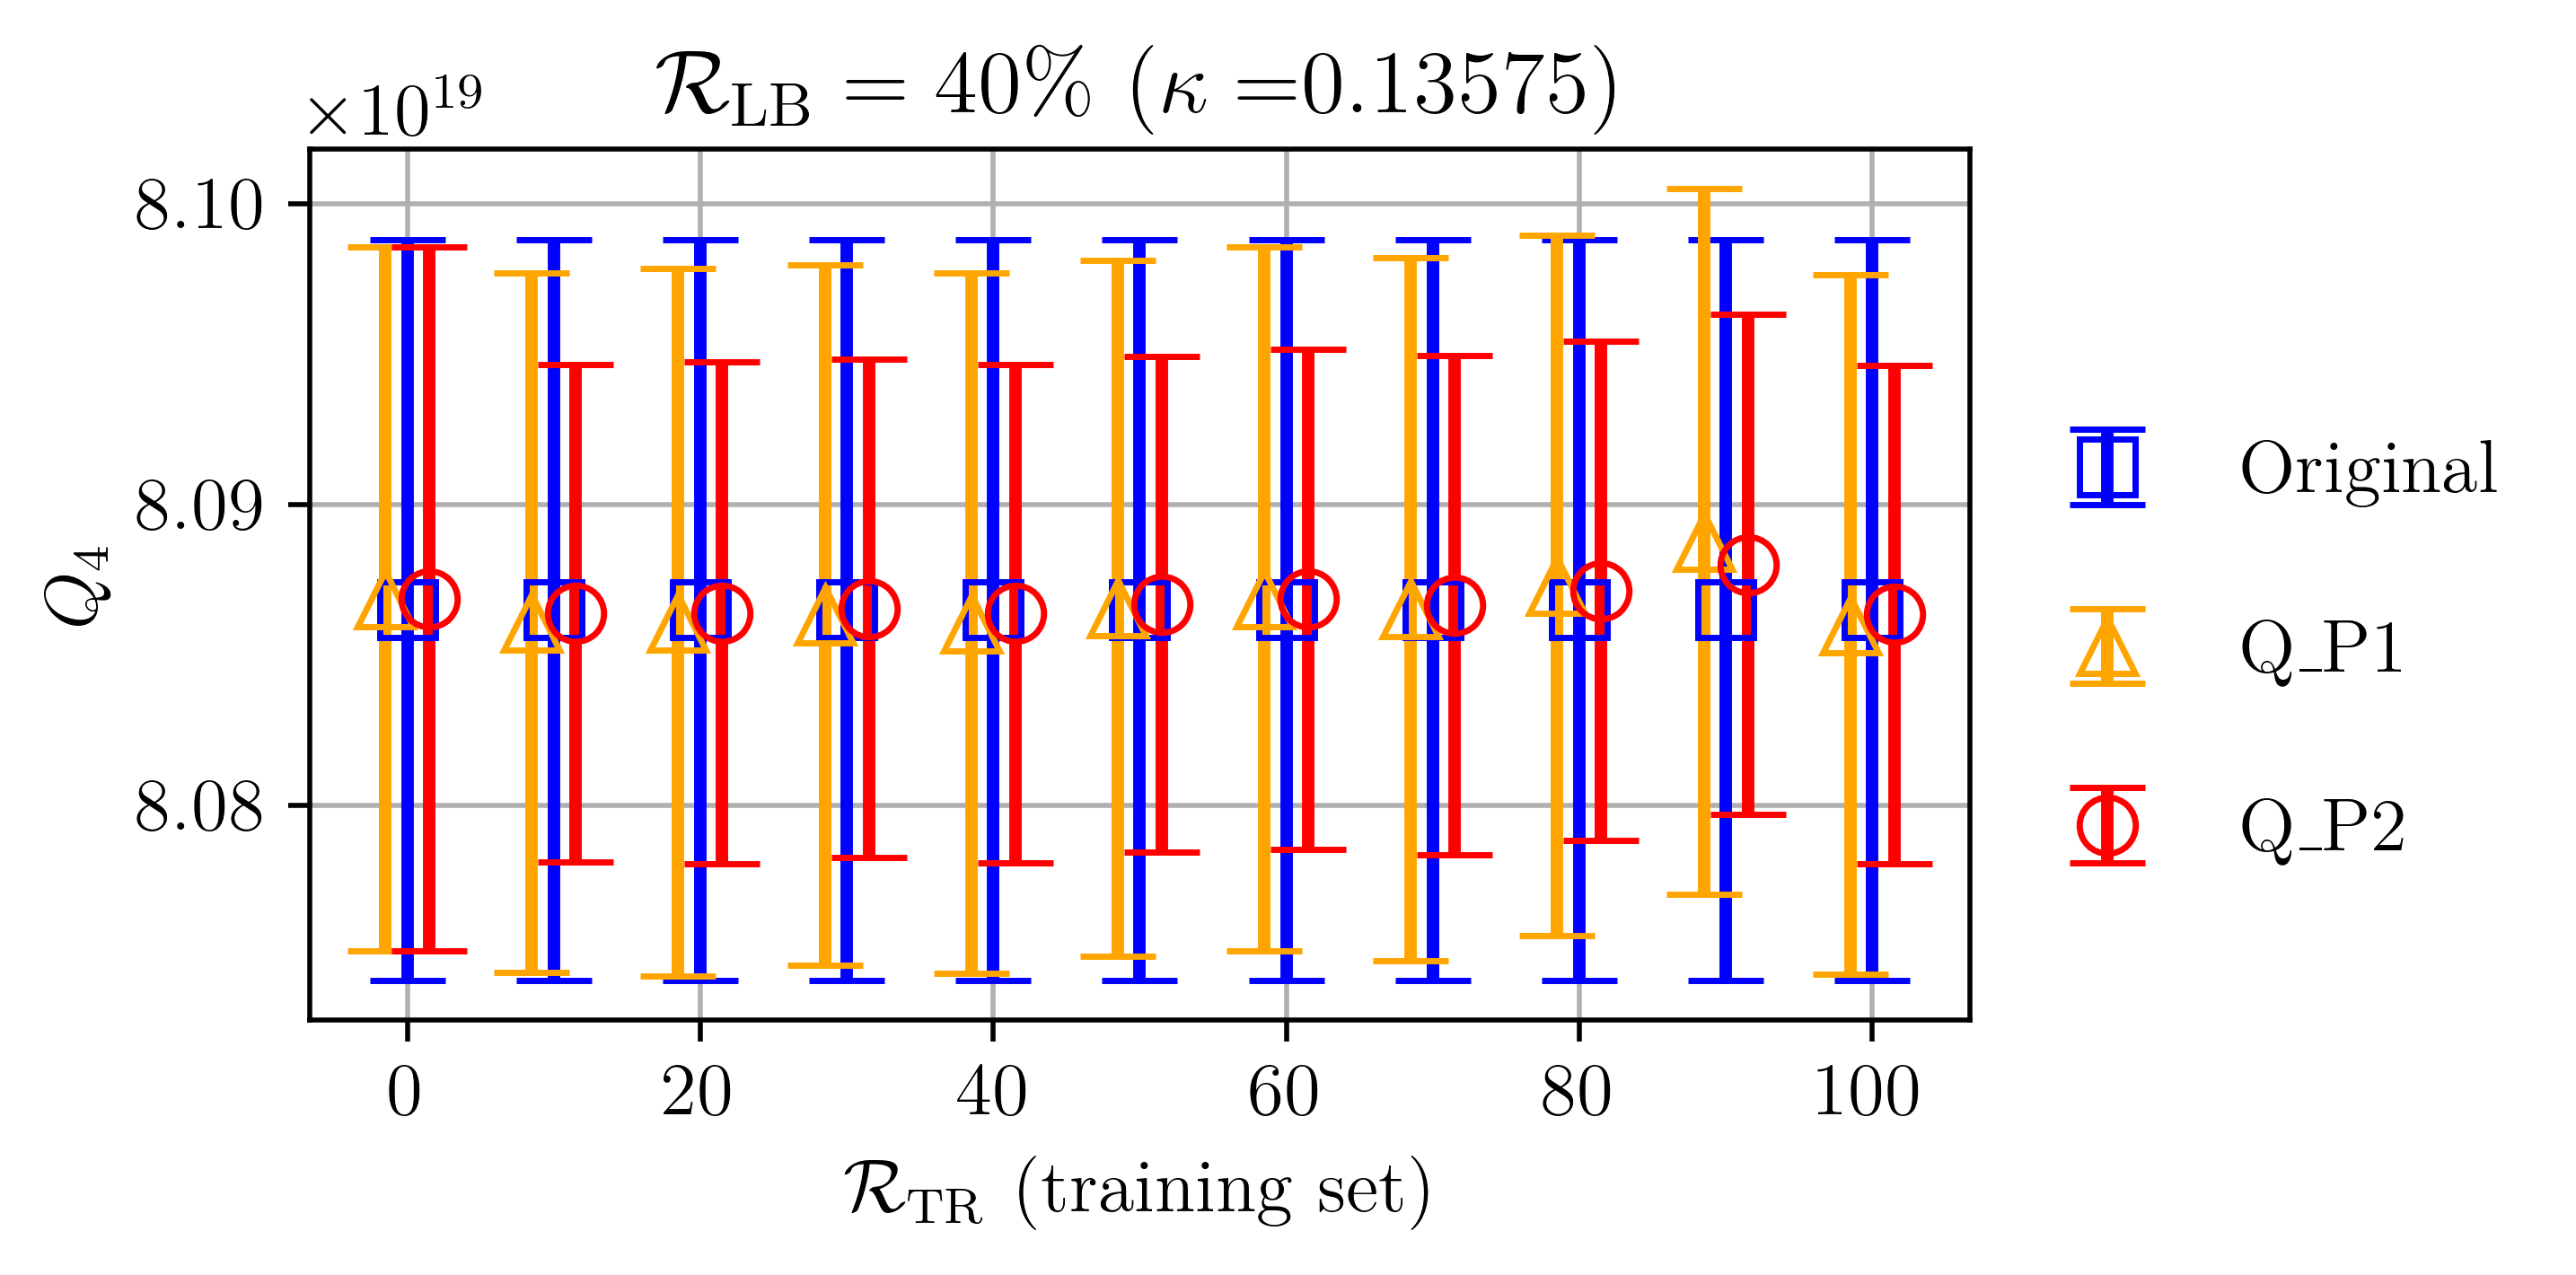

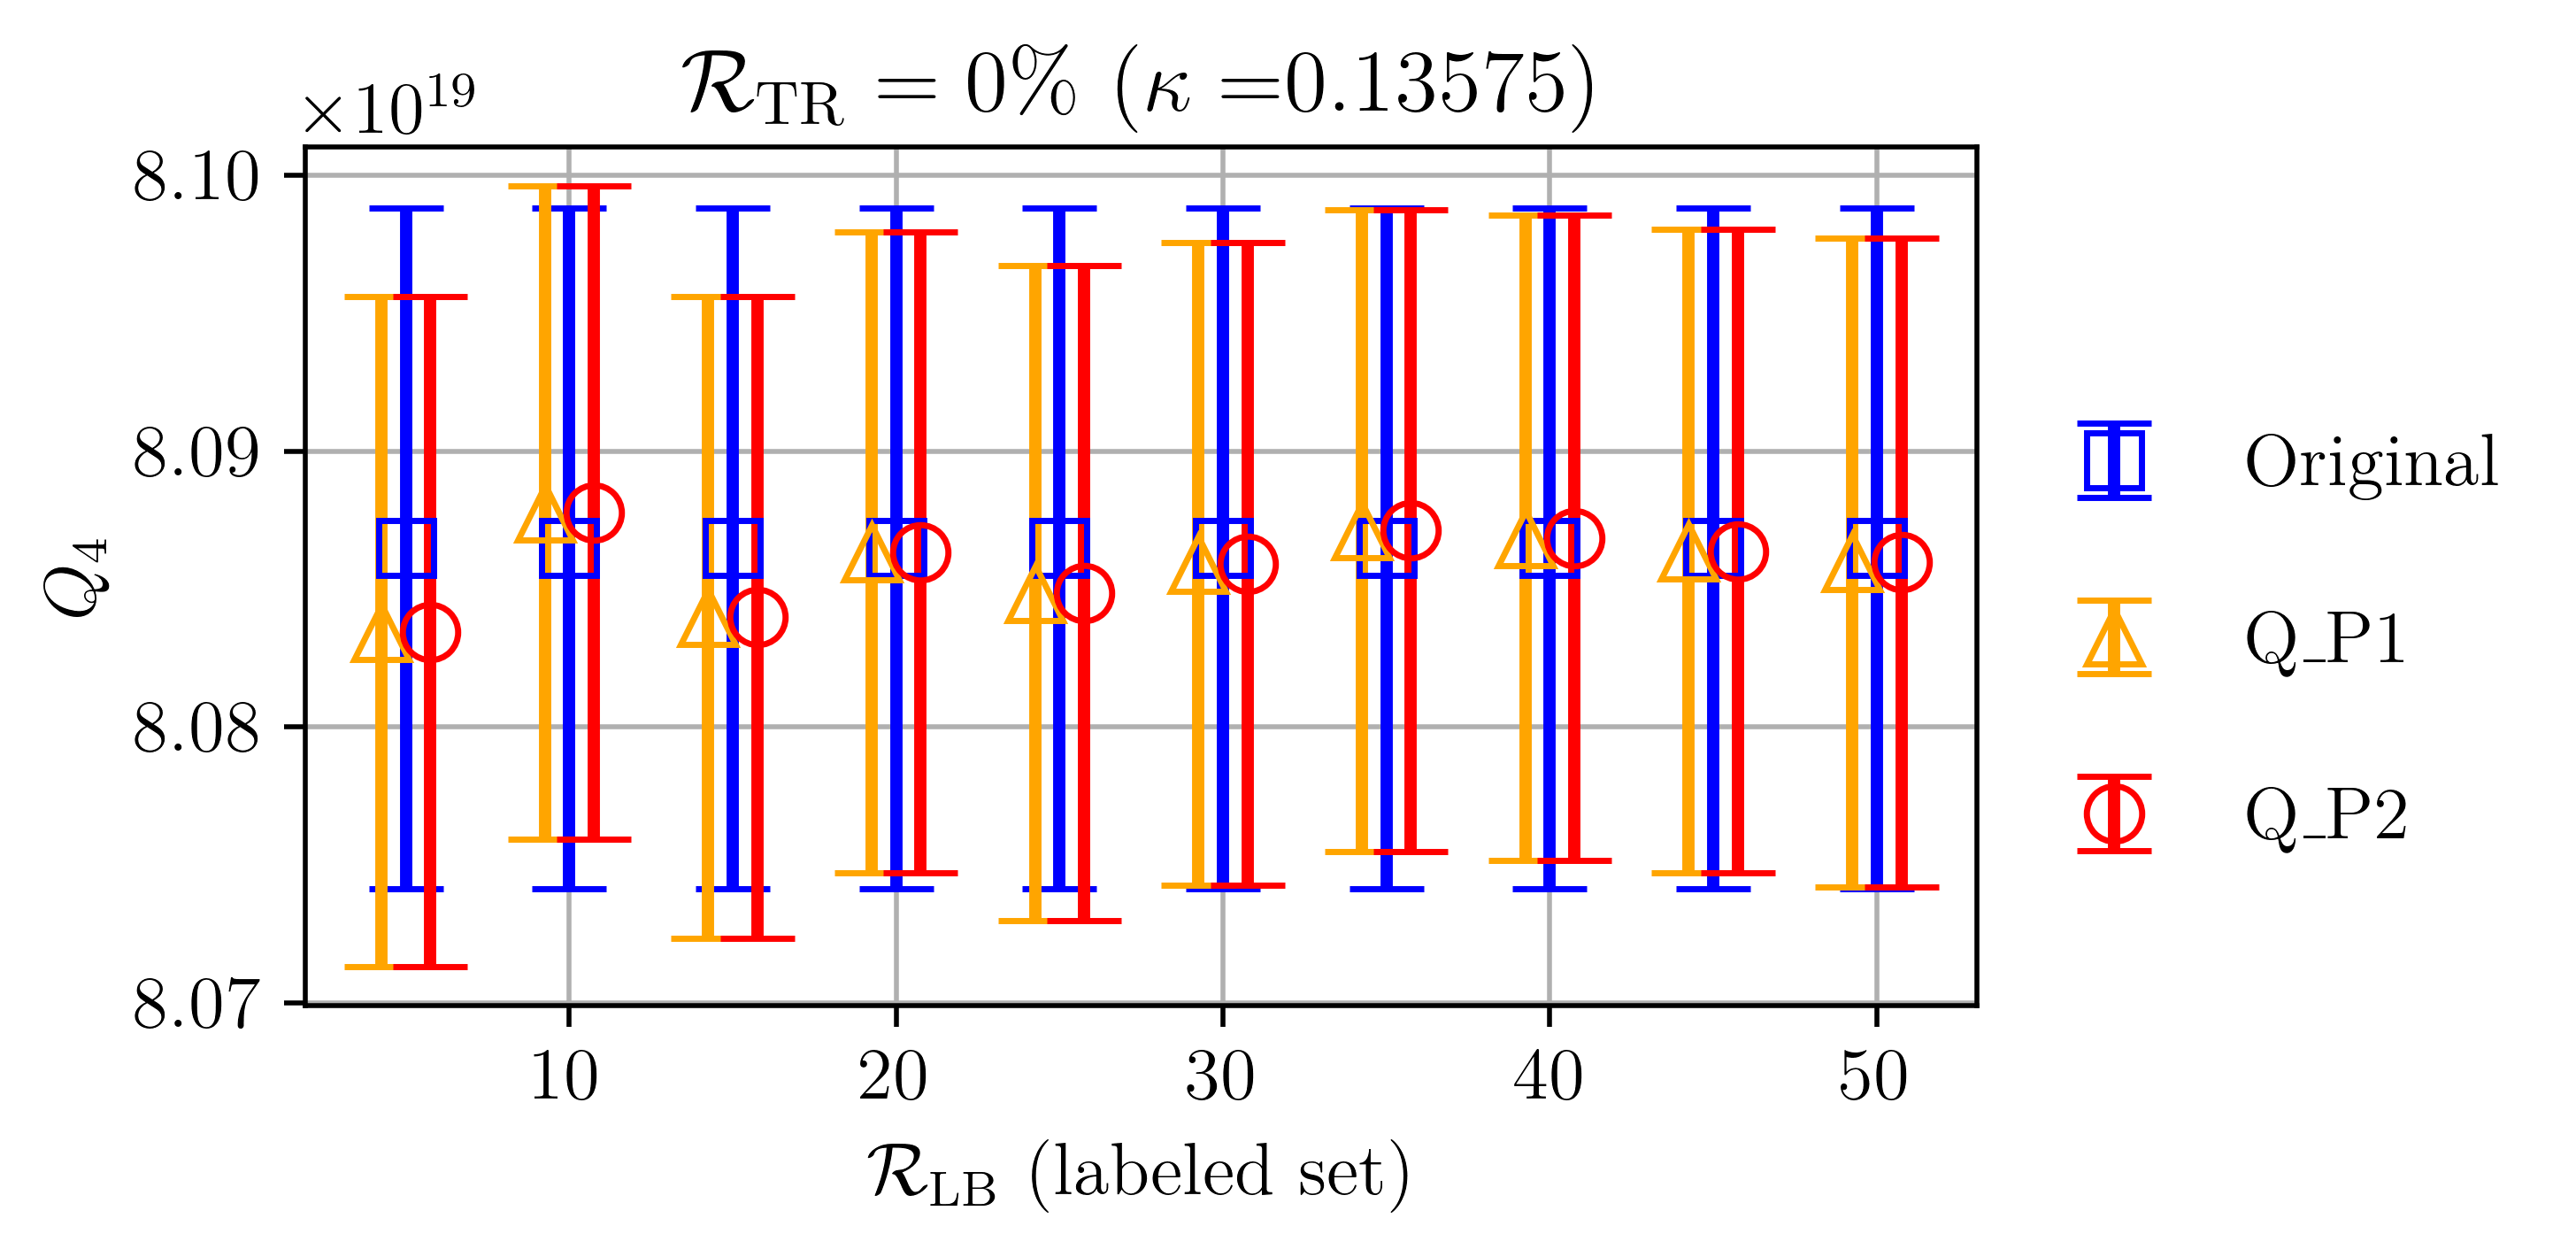

In [8]:
chosen_LBP = 40
chosen_TRP = 0

RebekahMiriam.PXvsBSPlotterRebekahMiriam.plot_PX_BS_vs_trains_for_measurements(
	String(chosen_key), 
	String(orig_tag), 
    String(:Q_P1),
    String(:Q_P2),
	chosen_LBP,
	RebekahMiriam.PXvsBSPlotterRebekahMiriam.build_flat_plot_dict(
		chosen_key,
		orig_tag, 
		:Q_P1, 
		:Q_P2, 
		chosen_keyword, 
		new_dict_moment_meas
	),
	trains_int, 
	labels_int,
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)

RebekahMiriam.PXvsBSPlotterRebekahMiriam.plot_PX_BS_vs_labels_for_measurements(
	String(chosen_key), 
	String(orig_tag), 
    String(:Q_P1),
    String(:Q_P2),
	chosen_TRP,
	RebekahMiriam.PXvsBSPlotterRebekahMiriam.build_flat_plot_dict(
		chosen_key, 
		orig_tag,
		:Q_P1, 
		:Q_P2, 
		chosen_keyword, 
		new_dict_moment_meas
	),
	labels_int, 
	trains_int,
	chosen_keyword,
	overall_name,
	PROJECT_ROOT;
	key_tex=chosen_key_tex,
	save_file=save_flag
)